# Autocomplete and Autocorrect Data Analytics

## Objective

The objective of this project is to analyze and enhance text prediction techniques by exploring autocomplete and autocorrect algorithms in natural language processing (NLP). Using a real-world text dataset, the project focuses on preprocessing textual data, implementing word prediction and spelling correction methods, evaluating their performance, and visualizing insights to understand their impact on user experience.

## Dataset Description

The dataset used in this project is the SMS Spam Collection dataset, which consists of real-world text messages. Each record contains a short message written in natural language, making the dataset suitable for natural language processing tasks such as autocomplete and autocorrect analysis.

The dataset provides sufficient textual diversity, including informal language, abbreviations, and spelling variations. This makes it ideal for studying word prediction, spelling correction, and user text input behavior in practical applications.

## Data Loading and Initial Text Inspection

In this step, the text dataset is loaded and examined to understand its structure and content.  
Initial inspection helps identify the text column, check for missing values, and gain an overview of the data before applying NLP preprocessing techniques.

In [1]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
df.shape

(5572, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


## NLP Preprocessing

In this step, the text data is cleaned and prepared for analysis.  
NLP preprocessing includes converting text to lowercase, removing punctuation and special characters, and tokenizing the text into individual words.  
This process ensures consistency and improves the accuracy of autocomplete and autocorrect algorithms.

In [4]:
import re
import string

df = df[['v1', 'v2']]
df.columns = ['Label', 'Text']

df['Text'] = df['Text'].str.lower()

df['Text'] = df['Text'].apply(
    lambda x: re.sub(f"[{string.punctuation}0-9]", "", x)
)
df.head()

,Label,Text
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [5]:
# Tokenize text into words
df['Tokens'] = df['Text'].apply(lambda x: x.split())
df.head()

,Label,Text,Tokens
0,ham,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,ham,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,spam,free entry in a wkly comp to win fa cup final...,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,ham,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,ham,nah i dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l..."


## Exploratory Text Analysis

This section explores the textual data by analyzing word frequencies and vocabulary size.  
Understanding commonly used words helps in building effective autocomplete and autocorrect algorithms, as frequent words are more likely to be predicted or corrected during user input.

In [6]:
from collections import Counter
# Combine all tokens into a single list
all_words = [word for tokens in df['Tokens'] for word in tokens]
word_freq = Counter(all_words)
word_freq.most_common(10)

[('to', 2240),
 ('i', 2233),
 ('you', 2122),
 ('a', 1428),
 ('the', 1320),
 ('u', 1139),
 ('and', 970),
 ('in', 887),
 ('is', 886),
 ('me', 784)]

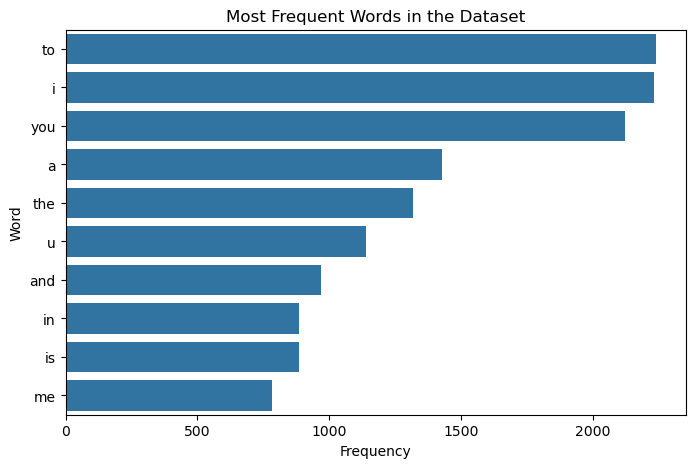

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

freq_df = pd.DataFrame(word_freq.most_common(10), columns=['Word', 'Frequency'])

# Plot most common words
plt.figure(figsize=(8, 5))
sns.barplot(x='Frequency', y='Word', data=freq_df)
plt.title("Most Frequent Words in the Dataset")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

## Autocomplete Implementation

Autocomplete predicts the next word in a sequence based on previously typed words.  
In this project, an n-gram based language model is used, where word sequences are learned from the dataset and the most probable next word is suggested based on frequency.

In [8]:
from collections import defaultdict

# Create bigram model
bigrams = defaultdict(list)

for tokens in df['Tokens']:
    for i in range(len(tokens) - 1):
        bigrams[tokens[i]].append(tokens[i + 1])

bigram_freq = {
    key: Counter(value) for key, value in bigrams.items()
}

In [9]:
def autocomplete(word, model, top_n=3):
    if word in model:
        return model[word].most_common(top_n)
    else:
        return []

In [10]:
# Test autocomplete
autocomplete("i", bigram_freq)

[('am', 138), ('will', 98), ('dont', 85)]

## Autocorrect Implementation

Autocorrect focuses on identifying and correcting spelling errors in user input.  
In this project, an edit-distance–based approach is used to suggest the most likely correct word by comparing the input with words from the dataset vocabulary.

In [11]:
# Create vocabulary from dataset
vocab = set(all_words)
len(vocab)

8749

In [12]:
def edit_distance(word1, word2):
    dp = [[0] * (len(word2) + 1) for _ in range(len(word1) + 1)]

    for i in range(len(word1) + 1):
        dp[i][0] = i
    for j in range(len(word2) + 1):
        dp[0][j] = j

    for i in range(1, len(word1) + 1):
        for j in range(1, len(word2) + 1):
            if word1[i - 1] == word2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(
                    dp[i - 1][j],     # deletion
                    dp[i][j - 1],     # insertion
                    dp[i - 1][j - 1]  # substitution
                )
    return dp[-1][-1]

In [13]:
def autocorrect(word, vocabulary, max_distance=2):
    suggestions = []
    for vocab_word in vocabulary:
        distance = edit_distance(word, vocab_word)
        if distance <= max_distance:
            suggestions.append((vocab_word, distance))
    return sorted(suggestions, key=lambda x: x[1])[:5]

In [14]:
# Test autocorrect
autocorrect("mesage", vocab)

[('message', 1),
 ('mesages', 1),
 ('messages', 2),
 ('meare', 2),
 ('messaged', 2)]

## Performance Metrics and Evaluation

In this step, simple performance metrics are used to evaluate the effectiveness of the autocomplete and autocorrect algorithms.  
For autocomplete, the correctness of predicted next words is examined.  
For autocorrect, the ability to suggest the correct word within a small edit distance is analyzed.

In [15]:
# Simple evaluation for autocomplete
test_words = ["i", "you", "free", "call"]

for word in test_words:
    predictions = autocomplete(word, bigram_freq)
    print(f"Input word: '{word}' → Predictions: {predictions}")

Input word: 'i' → Predictions: [('am', 138), ('will', 98), ('dont', 85)]
Input word: 'you' → Predictions: [('are', 127), ('have', 117), ('know', 60)]
Input word: 'free' → Predictions: [('call', 18), ('entry', 16), ('on', 15)]
Input word: 'call' → Predictions: [('now', 62), ('me', 59), ('from', 49)]


In [16]:
# Test autocorrect on common misspellings
test_misspellings = ["mesage", "recieve", "fre", "helo"]

for word in test_misspellings:
    corrections = autocorrect(word, vocab)
    print(f"Misspelled word: '{word}' → Suggestions: {corrections}")

Misspelled word: 'mesage' → Suggestions: [('message', 1), ('mesages', 1), ('messages', 2), ('meare', 2), ('messaged', 2)]
Misspelled word: 'recieve' → Suggestions: [('recieve', 0), ('relieved', 2), ('believe', 2), ('retrieve', 2), ('receive', 2)]
Misspelled word: 'fre' → Suggestions: [('ore', 1), ('fret', 1), ('fr', 1), ('free', 1), ('ure', 1)]
Misspelled word: 'helo' → Suggestions: [('held', 1), ('hell', 1), ('hello', 1), ('help', 1), ('horo', 2)]


## Algorithm Comparison and Visualization

This section compares the performance and behavior of the implemented autocomplete and autocorrect algorithms.  
Autocomplete predictions are based on word frequency using n-grams, while autocorrect relies on edit distance for spelling correction.  
Visualization is used to support the comparison and better understand algorithm efficiency and prediction trends.

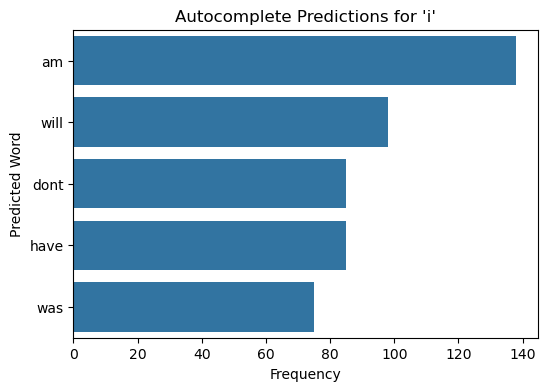

In [17]:
# Visualize most common next-word predictions for a sample word
sample_word = "i"

if sample_word in bigram_freq:
    pred_df = pd.DataFrame(
        bigram_freq[sample_word].most_common(5),
        columns=["Next Word", "Frequency"]
    )
    plt.figure(figsize=(6, 4))
    sns.barplot(x="Frequency", y="Next Word", data=pred_df)
    plt.title(f"Autocomplete Predictions for '{sample_word}'")
    plt.xlabel("Frequency")
    plt.ylabel("Predicted Word")
    plt.show()

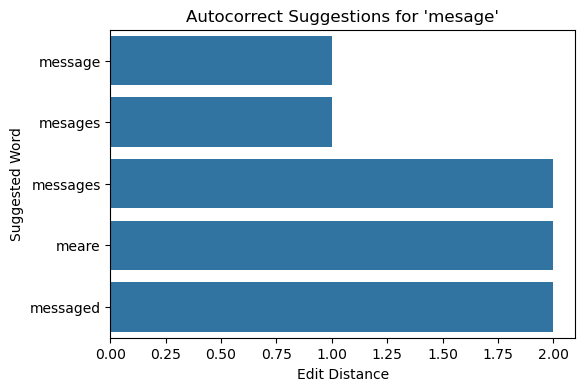

In [18]:
# Visualize edit distances for autocorrect suggestions
test_word = "mesage"
suggestions = autocorrect(test_word, vocab)

dist_df = pd.DataFrame(suggestions, columns=["Suggested Word", "Edit Distance"])

plt.figure(figsize=(6, 4))
sns.barplot(x="Edit Distance", y="Suggested Word", data=dist_df)
plt.title(f"Autocorrect Suggestions for '{test_word}'")
plt.xlabel("Edit Distance")
plt.ylabel("Suggested Word")
plt.show()

## User Experience Impact and Conclusion

The analysis and implementation of autocomplete and autocorrect algorithms demonstrate their significant impact on improving user experience in text-based applications. Autocomplete functionality enhances typing efficiency by predicting commonly used words, reducing user effort and input time. Autocorrect helps minimize spelling errors, ensuring clearer and more accurate communication.

The project successfully applied natural language processing techniques, including text preprocessing, word frequency analysis, n-gram based prediction, and edit-distance based spelling correction. Performance evaluation and algorithm comparison highlighted the strengths of each approach in terms of efficiency and accuracy.

Overall, this project provides practical insights into how autocomplete and autocorrect systems function and how they contribute to better usability in modern text input systems, fulfilling the objectives of data analytics and NLP-based user experience enhancement.